In [60]:
import numpy as np 
import matplotlib.pyplot as plt
import nidaqmx
import matplotlib.animation as animation
from nidaqmx.constants import AcquisitionType, TerminalConfiguration
import datetime as datetime
from IPython.display import clear_output
import time
import pyvisa

In [22]:
#para saber el ID de la placa conectada (DevX)
system = nidaqmx.system.System.local()
for device in system.devices:
    print(device)

Device(name=Dev4)


In [62]:
rm = pyvisa.ResourceManager()
rm.list_resources()
fungen = rm.open_resource('USB0::0x0699::0x0346::C036492::INSTR')  # Replace with your function generator's VISA address

In [50]:
def save_measurement(t, V, comment=""):
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"data_forzado/measurement_{timestamp}.csv"
    
    header = f"Comment: {comment}\nTime (s),Voltage (V)"
    data = np.column_stack((t, V))
    
    np.savetxt(filename, data, delimiter=",", header=header, comments="")
    print(f"Saved to {filename}")

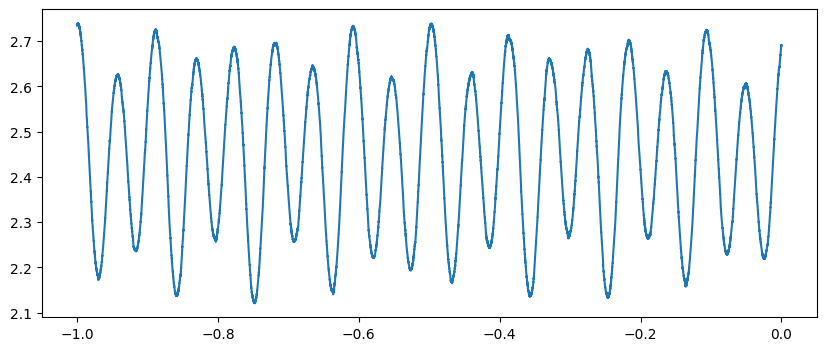

Collected 250000 samples (10.00 seconds)


In [172]:
sample_rate = 25000
samples_per_read = 2500
buffer_size = 25000        # se muestra solamente un segundo de data
duration_seconds = 10
channel_name = "Dev4/ai1"

task = nidaqmx.Task()

task.ai_channels.add_ai_voltage_chan(
    channel_name, 
    terminal_config=TerminalConfiguration.RSE
)

task.timing.cfg_samp_clk_timing(
    sample_rate,
    sample_mode=AcquisitionType.CONTINUOUS,
    samps_per_chan=samples_per_read
)

task.start()

display_buffer = np.zeros(buffer_size)
all_data = []

# negativo pq es el segundo que ya paso jaj
time_axis = np.linspace(-buffer_size/sample_rate, 0, buffer_size)

start_time = time.time()


plot_interval = 0.2  # seconds
last_plot = time.time()

try:
    while (time.time() - start_time) < duration_seconds:
        data = task.read(number_of_samples_per_channel=samples_per_read)
        all_data.extend(data)

        display_buffer = np.roll(display_buffer, -samples_per_read)
        display_buffer[-samples_per_read:] = data

        if time.time() - last_plot > plot_interval:
            clear_output(wait=True)

            fig, ax = plt.subplots(figsize=(10,4))
            ax.plot(time_axis, display_buffer)
            plt.show()
            last_plot = time.time()

finally:
    task.stop()
    task.close()

all_data = np.array(all_data)
print(f"Collected {len(all_data)} samples ({len(all_data)/sample_rate:.2f} seconds)")


V = all_data
t = np.arange(len(V)) / sample_rate

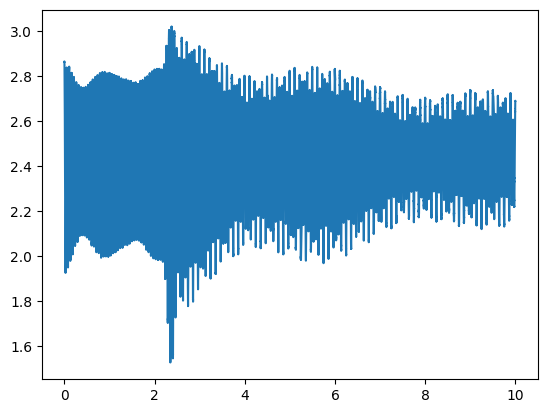

In [173]:
plt.plot(t,V)
# plt.xlim(0.45,2.5)
# plt.ylim(0,1)

In [ ]:
save_measurement(t, V, comment="Latón: segunda medicion, la mejor hasta ahora  distancia torreta a filo: 27.3 cm ")

Saved to data/measurement_20260611_125450.csv


In [174]:
# --- 1. Configuration ---
sample_rate = 25000
measurement_duration = 10  # seconds exactly
samples_per_measurement = int(sample_rate * measurement_duration) 
channel_name = "Dev4/ai1"

# Define the frequencies you want to sweep through
frequencies = [42,40,38,36,34,32,30,28,26,24,22,20,18,16,14,12,10] # Example frequencies in Hz

# --- 2. DAQmx Task Setup ---
# Using a 'with' block automatically handles task.close() even if the script crashes
with nidaqmx.Task() as task:
    
    task.ai_channels.add_ai_voltage_chan(
        channel_name, 
        terminal_config=TerminalConfiguration.RSE
    )

    # Switch to FINITE sampling. 
    # The task will automatically stop once it reads the exact number of samples.
    task.timing.cfg_samp_clk_timing(
        sample_rate,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=samples_per_measurement
    )

    # --- 3. Frequency Sweep Loop ---
    for freq in frequencies:
        print(f"\n--- Preparing for {freq} Hz ---")
        
        # NOTE: If you are controlling the signal generator via Python, add that code here!
        # Example: function_generator.set_frequency(freq)
        # time.sleep(0.5) # Give the physical signal a half-second to stabilize

        fungen.write(f':SOURce1:FREQuency {freq}')
        
        time.sleep(0.5)


        print(f"Acquiring {measurement_duration} seconds of data...")
        
        task.start()
        
        # Read the exact chunk. Timeout is set slightly higher than the duration 
        # to ensure it doesn't timeout while waiting for the physical clock to finish.
        data = task.read(
            number_of_samples_per_channel=samples_per_measurement, 
            timeout=measurement_duration + 2.0
        )
        
        task.stop() # Stop the task so we can restart it cleanly on the next loop
        
        # --- 4. Process and Save ---
        V = np.array(data)
        t = np.arange(len(V)) / sample_rate
        
        # Pass the current frequency into your comment
        comment_string = f"Sweep Frequency: {freq} Hz"
        save_measurement(t, V, comment=comment_string)

print("\nFrequency sweep complete!")


--- Preparing for 42 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_134913.csv

--- Preparing for 40 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_134924.csv

--- Preparing for 38 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_134935.csv

--- Preparing for 36 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_134946.csv

--- Preparing for 34 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_134958.csv

--- Preparing for 32 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_135009.csv

--- Preparing for 30 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_135020.csv

--- Preparing for 28 Hz ---
Acquiring 10 seconds of data...
Saved to data_forzado/measurement_20260618_135031.csv

--- Preparing for 26 Hz ---
Acquiring 10 seconds of data...
Saved to data_forza

In [180]:
data = np.loadtxt(r"data_forzado\measurement_20260618_135031.csv", delimiter=",", skiprows=2)  # Adjust filename as needed

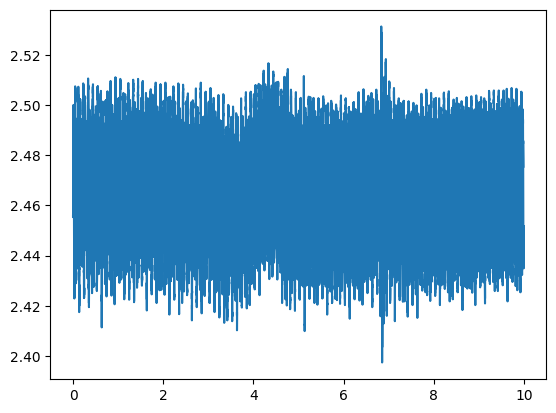

In [181]:
plt.plot(data[:,0], data[:,1])
# plt.xlim(0,1)